In [1]:
import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CLASS_DATA_PATH = "/kaggle/input/modality-aware-ssl-vit/MRI IMAGES"
SSL_DATA_PATH = "/kaggle/input/modality-aware-ssl-vit/BraTS_SSL-20260304T062029Z-1-001"

TRAIN_DIR = os.path.join(CLASS_DATA_PATH, "Training")
TEST_DIR = os.path.join(CLASS_DATA_PATH, "Testing")

print("Training folder:", TRAIN_DIR)
print("Testing folder:", TEST_DIR)

Device: cuda
Training folder: /kaggle/input/modality-aware-ssl-vit/MRI IMAGES/Training
Testing folder: /kaggle/input/modality-aware-ssl-vit/MRI IMAGES/Testing


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from torchvision import datasets, transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
SSL_DATA_PATH = "/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/BraTS_SSL-20260304T062029Z-1-001/BraTS_SSL"

CLASS_DATA_PATH = "/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES"

TRAIN_DIR = f"{CLASS_DATA_PATH}/Training"
TEST_DIR = f"{CLASS_DATA_PATH}/Testing"

print(TRAIN_DIR)
print(TEST_DIR)

/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES/Training
/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES/Testing


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [6]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

num_classes = len(train_dataset.classes)

print("Classes:", train_dataset.classes)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [8]:
vit_baseline = vit_b_16(weights=None)

vit_baseline.heads = nn.Linear(768, num_classes)

vit_baseline = vit_baseline.to(device)

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(vit_baseline.parameters(), lr=1e-5)

EPOCHS = 8

vit_baseline.train()

for epoch in range(EPOCHS):

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = vit_baseline(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs,1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total

    print(f"Baseline Epoch {epoch+1}/{EPOCHS} Acc:{acc:.2f}%")

Baseline Epoch 1/8 Acc:60.24%
Baseline Epoch 2/8 Acc:80.18%
Baseline Epoch 3/8 Acc:84.56%
Baseline Epoch 4/8 Acc:86.26%
Baseline Epoch 5/8 Acc:87.25%
Baseline Epoch 6/8 Acc:88.41%
Baseline Epoch 7/8 Acc:89.46%
Baseline Epoch 8/8 Acc:90.35%


In [10]:
def evaluate_model(model, name):

    model.eval()

    all_preds=[]
    all_probs=[]
    all_labels=[]

    with torch.no_grad():

        for images,labels in test_loader:

            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)

            probs=torch.softmax(outputs,dim=1)

            _,preds=torch.max(outputs,1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc=accuracy_score(all_labels,all_preds)
    precision=precision_score(all_labels,all_preds,average="weighted")
    recall=recall_score(all_labels,all_preds,average="weighted")
    f1=f1_score(all_labels,all_preds,average="weighted")

    print(f"\n{name}")
    print("Accuracy:",acc)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1:",f1)

    cm=confusion_matrix(all_labels,all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=train_dataset.classes,
        yticklabels=train_dataset.classes
    )

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    y_true=label_binarize(all_labels,classes=range(num_classes))
    y_score=np.array(all_probs)

    plt.figure(figsize=(7,6))

    for i,class_name in enumerate(train_dataset.classes):

        fpr,tpr,_=roc_curve(y_true[:,i],y_score[:,i])
        roc_auc=auc(fpr,tpr)

        plt.plot(fpr,tpr,label=f"{class_name} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.title(name + " ROC Curve")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.show()

    return acc


ViT Baseline (No SSL)
Accuracy: 0.858886346300534
Precision: 0.8542339535106963
Recall: 0.858886346300534
F1: 0.8525438340534385


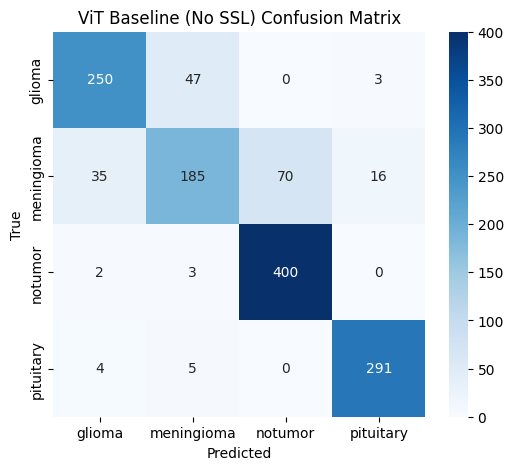

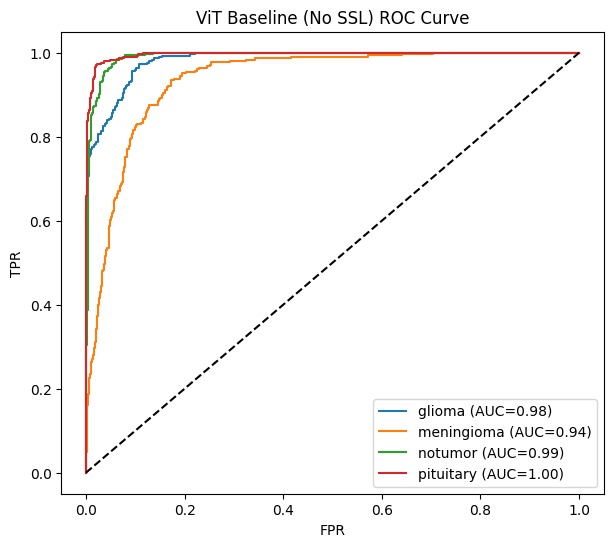

In [11]:
baseline_acc = evaluate_model(vit_baseline, "ViT Baseline (No SSL)")

In [12]:
encoder = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

encoder.heads = nn.Identity()

encoder = encoder.to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 193MB/s]


In [13]:
class MAEDecoder(nn.Module):

    def __init__(self, embed_dim=768):
        super().__init__()

        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )

    def forward(self, x):
        return self.decoder(x)

decoder = MAEDecoder().to(device)

In [14]:
optimizer = optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=1e-5
)

criterion = nn.MSELoss()

SSL_EPOCHS = 1

encoder.train()
decoder.train()

for epoch in range(SSL_EPOCHS):

    total_loss=0

    for images,_ in train_loader:

        images=images.to(device)

        optimizer.zero_grad()

        features=encoder(images)

        recon=decoder(features)

        loss=criterion(recon,features.detach())

        loss.backward()
        optimizer.step()

        total_loss+=loss.item()

    avg_loss=total_loss/len(train_loader)

    print("SSL Epoch",epoch+1,"Loss:",avg_loss)

SSL Epoch 1 Loss: 0.24960510282876106


In [15]:
torch.save(encoder.state_dict(),"ssl_encoder.pth")

In [16]:
model = vit_b_16(weights=None)

encoder_weights = torch.load("ssl_encoder.pth")

model.load_state_dict(encoder_weights, strict=False)

model.heads = nn.Linear(768, num_classes)

model = model.to(device)

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

criterion = nn.CrossEntropyLoss()

EPOCHS = 8

model.train()

for epoch in range(EPOCHS):

    correct=0
    total=0

    for images,labels in train_loader:

        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()
        optimizer.step()

        _,preds=torch.max(outputs,1)

        correct+=(preds==labels).sum().item()
        total+=labels.size(0)

    acc=100*correct/total

    print(f"SSL Epoch {epoch+1}/{EPOCHS} Acc:{acc:.2f}%")

SSL Epoch 1/8 Acc:73.98%
SSL Epoch 2/8 Acc:93.82%
SSL Epoch 3/8 Acc:97.41%
SSL Epoch 4/8 Acc:98.39%
SSL Epoch 5/8 Acc:98.93%
SSL Epoch 6/8 Acc:99.44%
SSL Epoch 7/8 Acc:99.82%
SSL Epoch 8/8 Acc:99.79%



ViT + SSL
Accuracy: 0.984744469870328
Precision: 0.9847887123688123
Recall: 0.984744469870328
F1: 0.9847377823855661


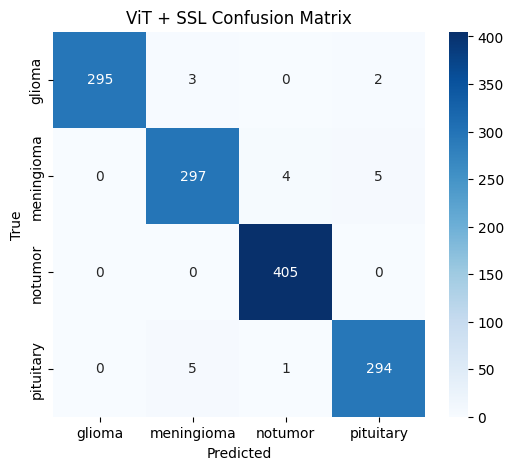

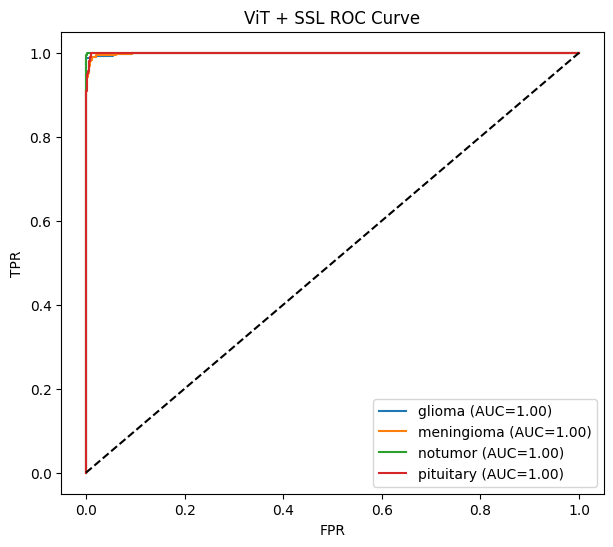

In [18]:
ssl_acc = evaluate_model(model, "ViT + SSL")

In [19]:
import os

dataset_path = "/kaggle/input"

for root, dirs, files in os.walk(dataset_path):
    if len(files) > 0:
        print(root, ":", len(files))

/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/BraTS_SSL-20260304T062029Z-1-001/BraTS_SSL : 3875
/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES/Training/pituitary : 1457
/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES/Training/notumor : 1595
/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES/Training/meningioma : 1339
/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES/Training/glioma : 1321
/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES/Testing/pituitary : 300
/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES/Testing/notumor : 405
/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES/Testing/meningioma : 306
/kaggle/input/datasets/subasriuvaraj004/dataset-modality-aware-ssl/MRI IMAGES/MRI IMAGES/

In [20]:
torch.save(model.state_dict(), "final_model.pth")

In [21]:
import os
print(os.listdir('/kaggle/working'))

['__notebook__.ipynb', 'final_model.pth', 'ssl_encoder.pth']
